# Stochastic Reserving and Capital Modeling

In [65]:
import numpy as np
import pandas as pd
import chainladder as cl

np.random.seed(42)
triangle = cl.load_sample('genins')
triangle

,12,24,36,48,60,72,84,96,108,120
2001,"357,848","1,124,788","1,735,330","2,218,270","2,745,596","3,319,994","3,466,336","3,606,286","3,833,515","3,901,463"
2002,"352,118","1,236,139","2,170,033","3,353,322","3,799,067","4,120,063","4,647,867","4,914,039","5,339,085",
2003,"290,507","1,292,306","2,218,525","3,235,179","3,985,995","4,132,918","4,628,910","4,909,315",,
2004,"310,608","1,418,858","2,195,047","3,757,447","4,029,929","4,381,982","4,588,268",,,
2005,"443,160","1,136,350","2,128,333","2,897,821","3,402,672","3,873,311",,,,
2006,"396,132","1,333,217","2,180,715","2,985,752","3,691,712",,,,,
2007,"440,832","1,288,463","2,419,861","3,483,130",,,,,,
2008,"359,480","1,421,128","2,864,498",,,,,,,
2009,"376,686","1,363,294",,,,,,,,
2010,"344,014",,,,,,,,,


In [78]:
print(triangle.is_cumulative)

True


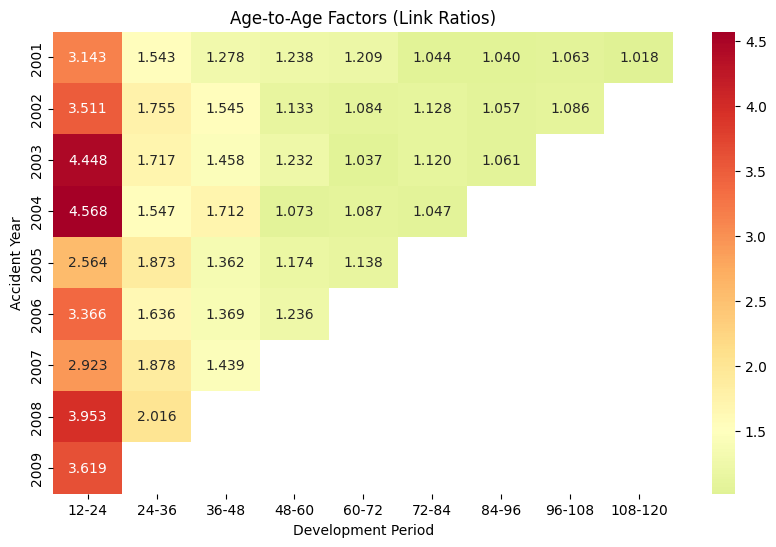

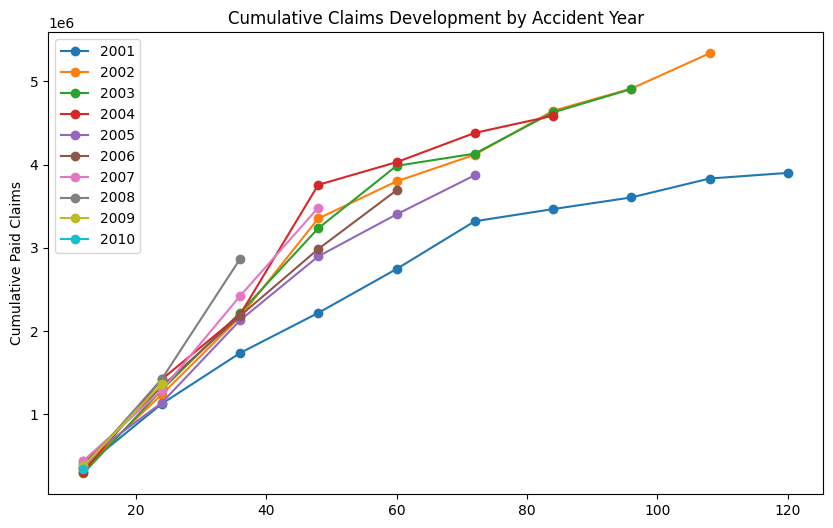

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Cumulative Triangle and Link Ratios (ATA factors)
# cum_triangle = triangle.cumsum()
ata = triangle.link_ratio

# Plot Heatmap of Link Ratios
plt.figure(figsize=(10, 6))
sns.heatmap(ata.to_frame(), annot=True, cmap='RdYlGn_r', center=1.5, fmt=".3f")
plt.title("Age-to-Age Factors (Link Ratios)")
plt.xlabel("Development Period")
plt.ylabel("Accident Year")
plt.show()

# Plot Cumulative Development Curves
triangle.T.plot(marker='o', figsize=(10,6))
plt.title("Cumulative Claims Development by Accident Year")
plt.ylabel("Cumulative Paid Claims")
plt.show()

In [67]:
# 1. Deterministic Chain Ladder
cl_model = cl.Chainladder().fit(triangle)
print("Deterministic IBNR:", cl_model.ibnr_.sum())


Deterministic IBNR: 18680855.611924313


In [82]:
# 2. Mack Chain Ladder (Analytical Variance)
mack_model = cl.MackChainladder().fit(triangle)
mack_summary = mack_model.summary_
summary_df = mack_summary.to_frame()
selected_columns = summary_df[['Latest', 'IBNR', 'Ultimate']]

print(selected_columns)
print(f"Total Mack Standard Error: {mack_model.total_mack_std_err_}")


               Latest          IBNR      Ultimate
2001-01-01  3901463.0           NaN  3.901463e+06
2002-01-01  5339085.0  9.463381e+04  5.433719e+06
2003-01-01  4909315.0  4.695113e+05  5.378826e+06
2004-01-01  4588268.0  7.096378e+05  5.297906e+06
2005-01-01  3873311.0  9.848886e+05  4.858200e+06
2006-01-01  3691712.0  1.419459e+06  5.111171e+06
2007-01-01  3483130.0  2.177641e+06  5.660771e+06
2008-01-01  2864498.0  3.920301e+06  6.784799e+06
2009-01-01  1363294.0  4.278972e+06  5.642266e+06
2010-01-01   344014.0  4.625811e+06  4.969825e+06
Total Mack Standard Error: columns         values
(Total,)  2.441364e+06


In [92]:
simulated_reserves = cl.BootstrapODPSample(n_sims=10000, random_state=42).fit(triangle).resampled_triangles_
simulated_reserves

,Triangle Summary
Valuation:,2010-12
Grain:,OYDY
Shape:,"(10000, 1, 10, 10)"
Index:,[Total]
Columns:,[values]


In [99]:
boot_model = cl.Chainladder().fit(simulated_reserves)
total_simulated_ibnr = boot_model.ibnr_.sum(axis=2).values.flatten()
total_simulated_ibnr

array([19058135.79380554, 17028132.53090898, 13665800.29339473, ...,
       13479666.0522246 , 16934463.01512874, 19632913.91193949])

In [100]:
clean_simulations = total_simulated_ibnr[~np.isnan(total_simulated_ibnr)]
print(clean_simulations)

[19058135.79380554 17028132.53090898 13665800.29339473 ...
 13479666.0522246  16934463.01512874 19632913.91193949]


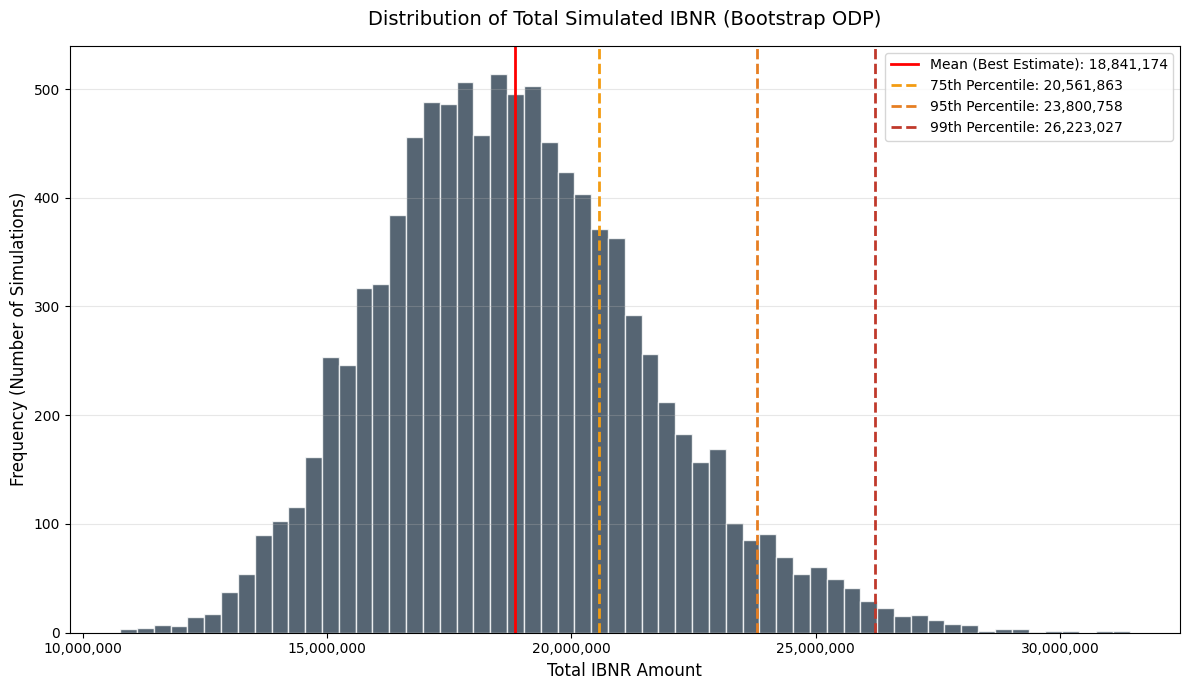

In [101]:
# Calculate VaR and CoV from the Bootstrap results
mean_reserve = np.mean(clean_simulations)
var_75 = np.percentile(clean_simulations, 75)
var_95 = np.percentile(clean_simulations, 95)
var_99 = np.percentile(clean_simulations, 99)

# Plot the IBNR Distribution
plt.figure(figsize=(12, 7))
plt.hist(clean_simulations, bins=60, color='#2c3e50', edgecolor='white', alpha=0.8)

# Add VaR lines
plt.axvline(mean_reserve, color='red', linestyle='solid', linewidth=2, label=f'Mean (Best Estimate): {mean_reserve:,.0f}')
plt.axvline(var_75, color='#f39c12', linestyle='dashed', linewidth=2, label=f'75th Percentile: {var_75:,.0f}')
plt.axvline(var_95, color='#e67e22', linestyle='dashed', linewidth=2, label=f'95th Percentile: {var_95:,.0f}')
plt.axvline(var_99, color='#c0392b', linestyle='dashed', linewidth=2, label=f'99th Percentile: {var_99:,.0f}')

plt.title("Distribution of Total Simulated IBNR (Bootstrap ODP)", fontsize=14, pad=15)
plt.xlabel("Total IBNR Amount", fontsize=12)
plt.ylabel("Frequency (Number of Simulations)", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Format the x-axis with commas for readability
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()